# California Housing
Utilizar el dataset california housing como ejemplo de problemas de regresión

In [75]:
#dependencies
import matplotlib.pyplot as plt #librería para hacer gráficos
import numpy as np #librería de matemática
import tensorflow as tf #herramienta para problemas de ML
import tensorflow_datasets as tfds #librería de datasets predeterminados de tensorflow
from tensorflow.keras import layers,models #librería de redes neuronales
import pandas as pd
from sklearn.cluster import KMeans
#http://scikit-learn.org/stable/


Para empezar importamos el dataset. El mismo consta de 4 listas de elementos:
- x_train: listado de observaciones para entrenar
- x_test: listado de observacioness para testear el modelo (una vez entrenado)
- y_train: listado de valor promedio del inmueble para la observación correspondiente (para entrenar)
- y_test: listado de valor promedio del inmueble para testear el modelo.

El objetivo de este ejercicio va a ser obtener un modelo de machine learning que nos permita predecir los precios de los inmuebles en base a distintos parámetros

In [2]:
#1. Importar el dataset 'mnist', con la información para entrenar.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.california_housing.load_data(
    version='large',
    path='california_housing.npz',
    test_split=0.2, #alocamos un 30% del dataset para testear el modelo una vez entrenado
    seed=113
)

El dataset tiene los siguientes parámetros (features) en base a un censo realizado en California -agrupados por manzana: cada observación es una manzana-:
- Latitud
- Longitud
- Edad promedio de los inmuebes (años)
- Cantidad de ambientes (el total de cada manzana)
- Cantidad de habitaciones
- Población viviendo en esa manzana
- Cantidad de hogares
- Mediana de ingresos (/10,000 USD)

In [37]:
headers = ["lon","lat","house_age","rooms","bedrooms","population","households","med_income"]
df_train = pd.DataFrame(x_train, columns= headers)
df_train['price'] = y_train
df_train

,lon,lat,house_age,rooms,bedrooms,population,households,med_income,price
0,-118.269997,34.090000,52.0,2327.0,555.0,1048.0,491.0,3.7847,252300.0
1,-118.360001,33.959999,21.0,1802.0,556.0,1286.0,557.0,2.7284,146900.0
2,-122.389999,37.759998,52.0,1877.0,427.0,712.0,398.0,3.9722,290900.0
3,-117.949997,33.919998,11.0,3127.0,706.0,1594.0,694.0,4.3426,141300.0
4,-122.519997,37.919998,24.0,421.0,64.0,163.0,75.0,14.5833,500001.0
...,...,...,...,...,...,...,...,...,...
16507,-122.029999,37.349998,19.0,3811.0,1227.0,1930.0,1153.0,3.5154,311400.0
16508,-118.440002,34.189999,19.0,3487.0,959.0,2278.0,835.0,2.6709,215500.0
16509,-122.339996,37.570000,52.0,2547.0,373.0,876.0,359.0,8.2598,500001.0
16510,-122.180000,37.889999,18.0,4845.0,735.0,1634.0,734.0,8.1489,499000.0


In [38]:
df_train.describe() # hacemos un análisis rápido de los datos incluídos en el dataset.

,lon,lat,house_age,rooms,bedrooms,population,households,med_income,price
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.00000
mean,-119.562256,35.625362,28.654131,2644.717041,539.574280,1433.272339,501.458344,3.870193,206796.43750
std,2.001168,2.129764,12.597469,2210.147705,426.147156,1156.362427,387.578613,1.897700,115419.15625
min,-124.349998,32.549999,1.000000,2.000000,1.000000,6.000000,1.000000,0.499900,14999.00000
25%,-121.790001,33.930000,18.000000,1451.000000,295.000000,789.000000,279.000000,2.564300,119100.00000
50%,-118.489998,34.250000,29.000000,2133.500000,436.000000,1172.000000,411.000000,3.535700,179450.00000
75%,-118.000000,37.709999,37.000000,3145.250000,649.000000,1735.000000,607.000000,4.738100,265000.00000
max,-114.309998,41.919998,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.00000


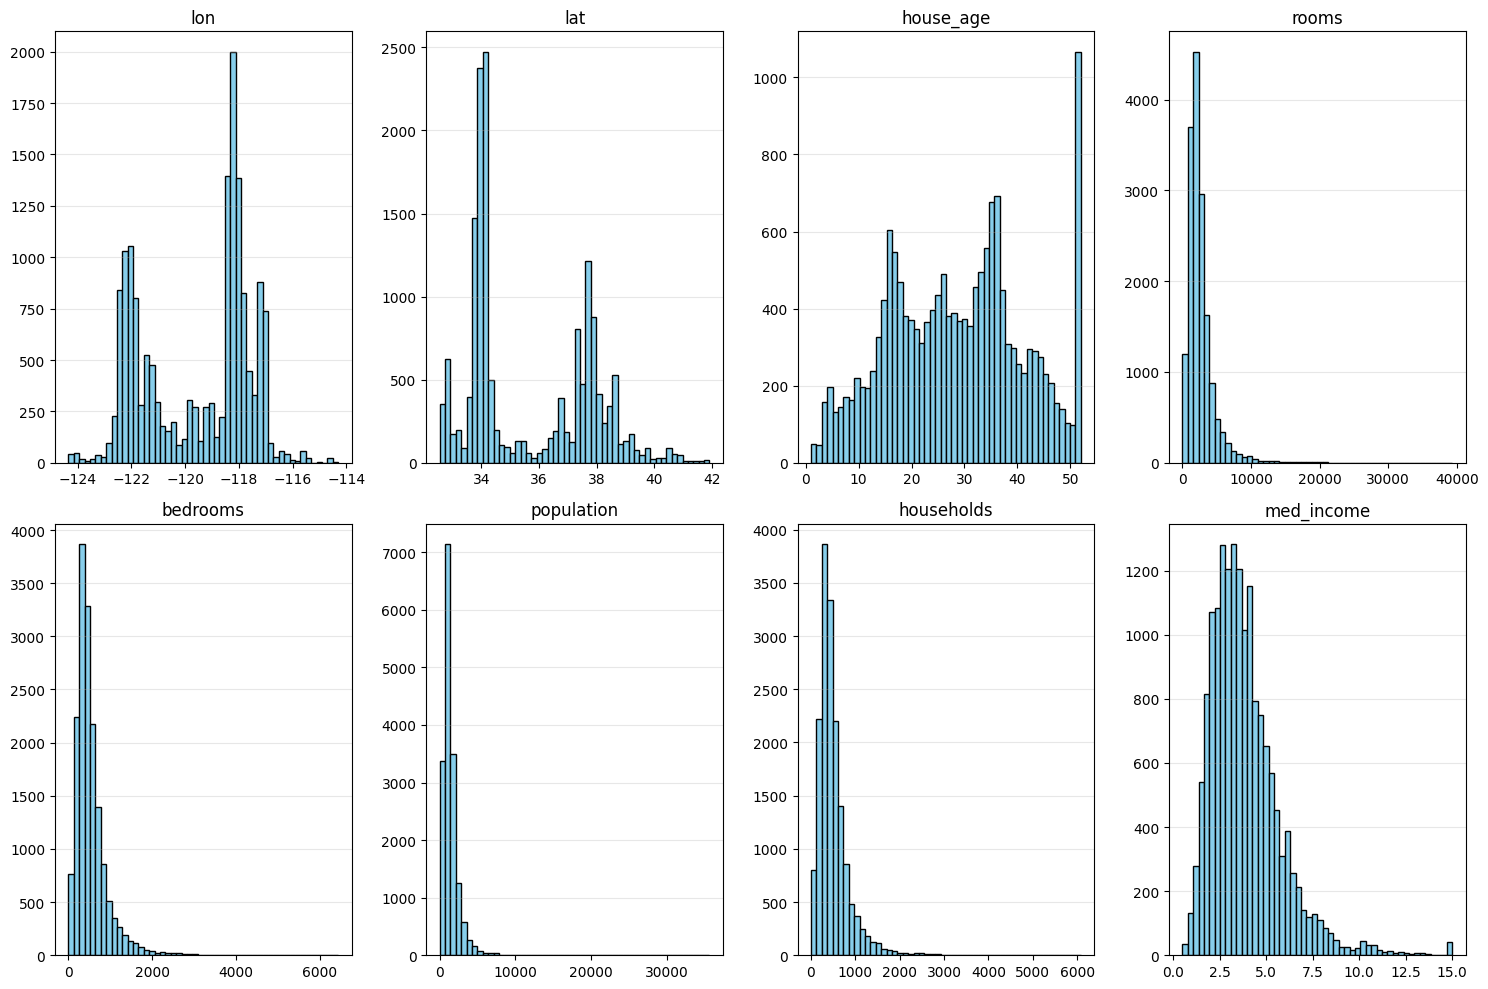

In [39]:
plt.figure(figsize=(15, 10))

features = df_train.columns

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.hist(df_train[features[i]], bins=50, color='skyblue', edgecolor='black')
    plt.title(features[i])
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

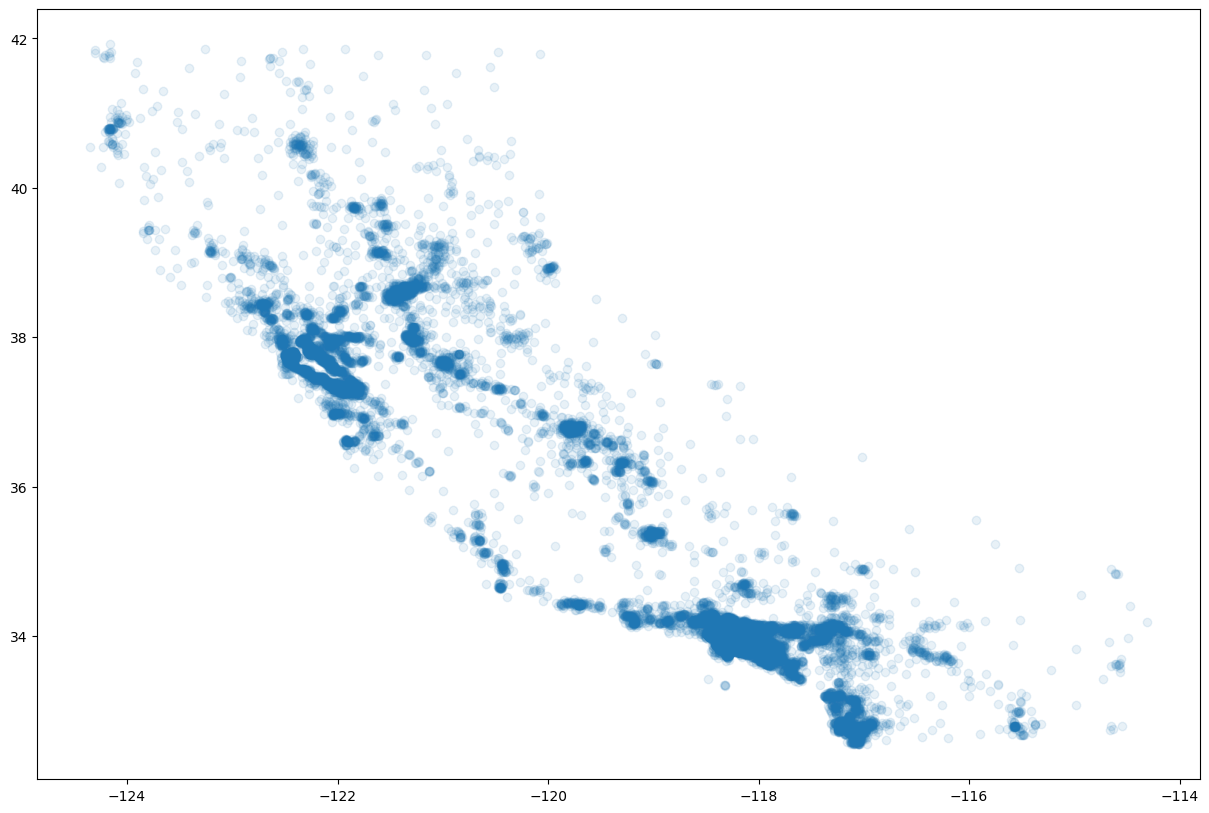

In [64]:
plt.figure(figsize=(15, 10))
plt.scatter(df_train['lon'], df_train['lat'], alpha=0.1)
plt.show()

In [65]:
clustermodel = KMeans(n_clusters=6, n_init=1, random_state=4)
clustermodel.fit(df_train.iloc[:, [0, 1]])

df_train['cluster'] = clustermodel.predict(df_train.iloc[:, [0, 1]])

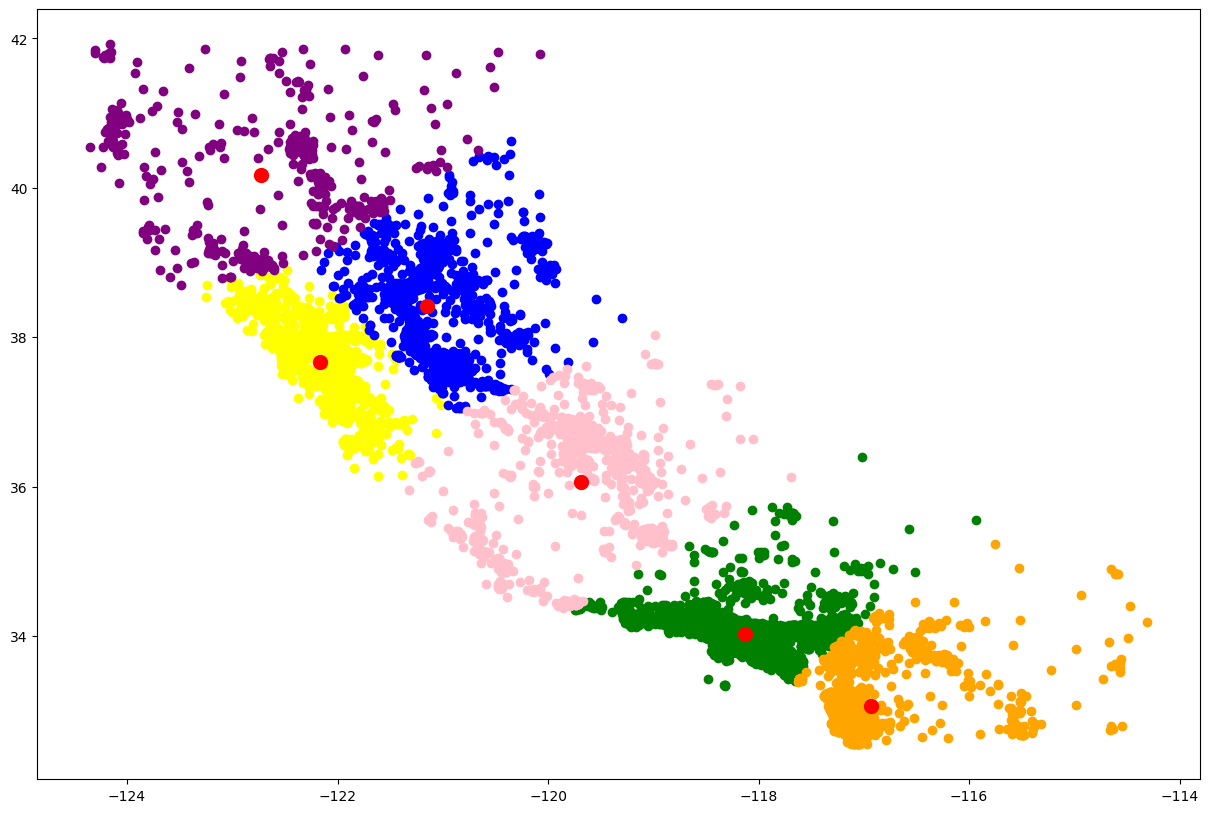

In [ ]:
df_cluster1 = df_train[df_train['cluster'] == 0]
df_cluster2 = df_train[df_train['cluster'] == 1]
df_cluster3 = df_train[df_train['cluster'] == 2]
df_cluster4 = df_train[df_train['cluster'] == 3]
df_cluster5 = df_train[df_train['cluster'] == 4]
df_cluster6 = df_train[df_train['cluster'] == 5]

plt.figure(figsize=(15, 10))
# plt.scatter(df_train['lon'], df_train['lat'], alpha=0.1)
plt.scatter(df_cluster1['lon'], df_cluster1['lat'], c='yellow')
plt.scatter(df_cluster2['lon'], df_cluster2['lat'], c='green')
plt.scatter(df_cluster3['lon'], df_cluster3['lat'], c='blue')
plt.scatter(df_cluster4['lon'], df_cluster4['lat'], c='orange')
plt.scatter(df_cluster5['lon'], df_cluster5['lat'], c='purple')
plt.scatter(df_cluster6['lon'], df_cluster6['lat'], c='pink')
plt.scatter(clustermodel.cluster_centers_[:, 0], clustermodel.cluster_centers_[:, 1], s=100, c='red')
plt.show()

In [ ]:
def model_features(sourcem,type):
    "hacemos una transformación homogénea de los datos"

    modeldf = pd.DataFrame()

    modeldf['latxlong'] = sourcem['lat'] * sourcem['lon'] 
    modeldf['avg_rooms'] = sourcem['rooms'] / sourcem['households']
    modeldf['avg_bedrooms'] = sourcem['bedrooms']/ sourcem['households']
    modeldf['avg_pop_house']= sourcem['population']/ sourcem['households']
    modeldf['beds_to_rooms'] = sourcem['bedrooms']/ sourcem['rooms']
    clusterq = sourcem['cluster'].nunique()
    for i in range(clusterq):
        modeldf['geocluster'+str(i)] = sourcem['cluster'] == i
    return modeldf

test_data = model_features(df_train,'train')
test_data

,latxlong,avg_rooms,avg_bedrooms,avg_pop_house,geocluster0,geocluster1,geocluster2,geocluster3,geocluster4,geocluster5
0,-4031.824219,4.739307,1.130346,2.134419,False,True,False,False,False,False
1,-4019.505615,3.235188,0.998205,2.308797,False,True,False,False,False,False
2,-4621.446289,4.716080,1.072864,1.788945,True,False,False,False,False,False
3,-4000.863770,4.505764,1.017291,2.296830,False,True,False,False,False,False
4,-4645.958008,5.613333,0.853333,2.173333,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
16507,-4557.820312,3.305290,1.064180,1.673894,True,False,False,False,False,False
16508,-4049.463623,4.176048,1.148503,2.728144,False,True,False,False,False,False
16509,-4596.313477,7.094707,1.038997,2.440111,True,False,False,False,False,False
16510,-4629.399902,6.600817,1.001362,2.226158,True,False,False,False,False,False
